In [1]:
!pip install -q datasets scikit-learn matplotlib pandas


In [14]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. In Colab choose Runtime → Change runtime type → T4 GPU.")


Device: cuda
GPU: Tesla T4


Training images: 50000
Testing images : 10000


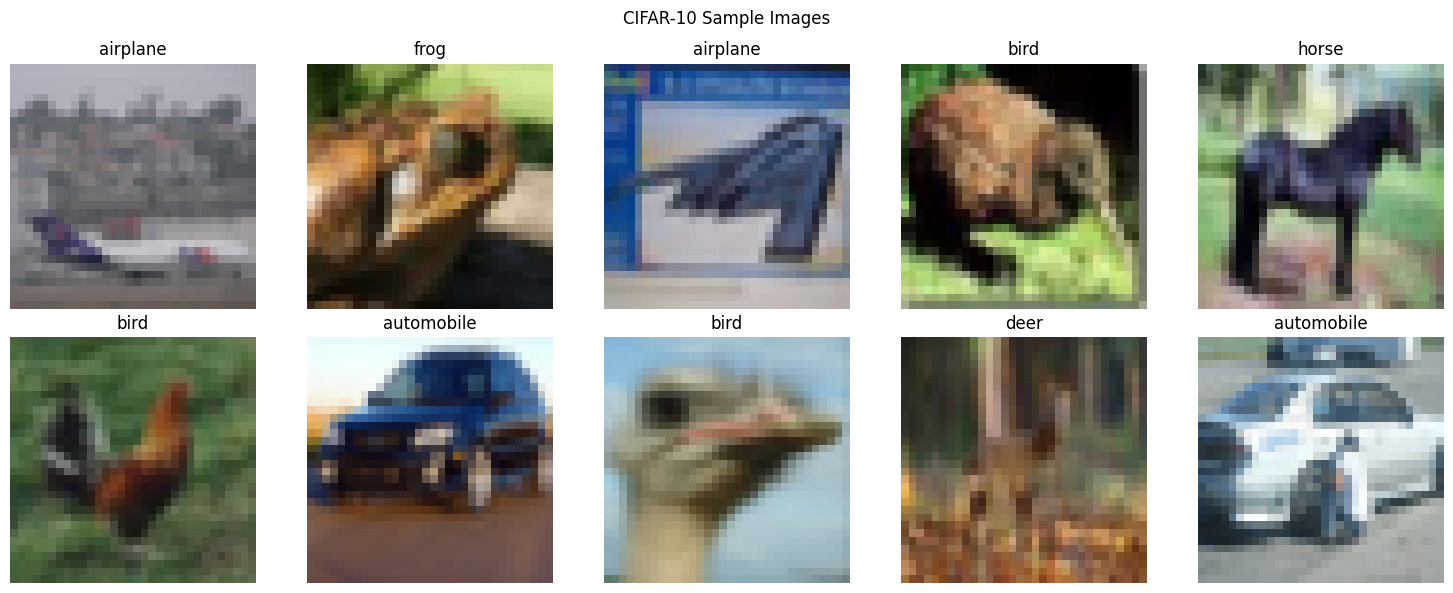


Training dataset:
Number of images: 50000
Image shape: torch.Size([3, 32, 32])

Testing dataset:
Number of images: 10000
Image shape: torch.Size([3, 32, 32])


In [15]:
# ============================================================
# TASK 1 - DATASET PREPARATION
# ============================================================

# CIFAR-10 class names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# ------------------------------------------------------------
# 1. Load CIFAR-10
# ------------------------------------------------------------

hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test = load_dataset("uoft-cs/cifar10", split="test")

print("Training images:", len(hf_train))
print("Testing images :", len(hf_test))


# ------------------------------------------------------------
# 2. Normalize pixel values to [0, 1]
# ------------------------------------------------------------
# ToTensor converts:
# 0 - 255  -->  0.0 - 1.0

transform = transforms.ToTensor()


# ------------------------------------------------------------
# PyTorch Dataset wrapper
# ------------------------------------------------------------

class CIFAR10TorchDataset(Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        item = self.dataset[index]

        image = item["img"]
        label = item["label"]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# Create Task 1 datasets
train_set = CIFAR10TorchDataset(
    hf_train,
    transform=transform
)

test_set = CIFAR10TorchDataset(
    hf_test,
    transform=transform
)


# ------------------------------------------------------------
# 3. Display 10 sample images
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

for i in range(10):

    image, label = train_set[i]

    # PyTorch: C x H x W
    # Matplotlib: H x W x C
    image = image.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("CIFAR-10 Sample Images")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Print dimensions
# ------------------------------------------------------------

sample_image, sample_label = train_set[0]

print("\nTraining dataset:")
print("Number of images:", len(train_set))
print("Image shape:", sample_image.shape)

print("\nTesting dataset:")
print("Number of images:", len(test_set))
print("Image shape:", test_set[0][0].shape)

In [16]:
from torch.utils.data import random_split

train_set, val_set = random_split(
    train_set,
    [40000, 10000],
    generator=torch.Generator().manual_seed(42)
)

print("Training images:", len(train_set))
print("Validation images:", len(val_set))
print("Testing images:", len(test_set))

Training images: 40000
Validation images: 10000
Testing images: 10000


In [17]:
img,label=train_set[0]
print("Original CIFAR-10 image: 32 x 32 x 3")
print("PyTorch tensor after resize:",img.shape)
print("Training set:",len(train_set)," Testing set:",len(test_set))

Original CIFAR-10 image: 32 x 32 x 3
PyTorch tensor after resize: torch.Size([3, 32, 32])
Training set: 40000  Testing set: 10000


In [8]:
# ============================================================
# TASK 2 - TRANSFER LEARNING WITH MOBILENETV2
# ============================================================


# ------------------------------------------------------------
# 1. Load pretrained ImageNet weights
# ------------------------------------------------------------

weights = MobileNet_V2_Weights.DEFAULT

backbone = mobilenet_v2(weights=weights)

print("Pretrained MobileNetV2 loaded.")


# ------------------------------------------------------------
# 2. MobileNetV2 preprocessing
# ------------------------------------------------------------

# MobileNetV2 was pretrained on ImageNet.
# This transform resizes CIFAR-10 images to 224 x 224
# and applies the ImageNet normalization.

transfer_transform = weights.transforms()


# ------------------------------------------------------------
# 3. Create separate datasets for Transfer Learning
# ------------------------------------------------------------

transfer_train_full = CIFAR10TorchDataset(
    hf_train,
    transform=transfer_transform
)

transfer_test_set = CIFAR10TorchDataset(
    hf_test,
    transform=transfer_transform
)


# ------------------------------------------------------------
# 4. Split training data
# ------------------------------------------------------------

transfer_train_set, transfer_val_set = random_split(
    transfer_train_full,
    [40000, 10000],
    generator=torch.Generator().manual_seed(42)
)

print("\nTransfer Learning datasets:")
print("Training   :", len(transfer_train_set))
print("Validation :", len(transfer_val_set))
print("Testing    :", len(transfer_test_set))


# ------------------------------------------------------------
# 5. DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    transfer_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=True
)

val_loader = DataLoader(
    transfer_val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=True
)

test_loader = DataLoader(
    transfer_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=True
)

print("Training batches:", len(train_loader))


# ------------------------------------------------------------
# 6. Freeze convolutional base
# ------------------------------------------------------------

for parameter in backbone.features.parameters():
    parameter.requires_grad = False


# ------------------------------------------------------------
# 7. Replace original classification layer
# ------------------------------------------------------------

class TransferMobileNetV2(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        # Frozen convolutional base
        self.features = backbone.features

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # New classifier
        self.classifier = nn.Sequential(

            nn.Flatten(),

            # Dense layer
            nn.Linear(1280, 128),

            # ReLU activation
            nn.ReLU(),

            # Output layer
            nn.Linear(128, 10)
        )

    def forward(self, x):

        # Convolutional base
        x = self.features(x)

        # Global Average Pooling
        x = self.gap(x)

        # Dense + ReLU + 10-class output
        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# 8. Create model
# ------------------------------------------------------------

model = TransferMobileNetV2(backbone).to(DEVICE)


# ------------------------------------------------------------
# 9. Check model
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\n========== MODEL ==========")
print("Model:", "MobileNetV2")
print("Device:", next(model.parameters()).device)
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")


# ------------------------------------------------------------
# 10. Test model output
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

# Softmax gives class probabilities
probabilities = torch.softmax(outputs, dim=1)

print("\n========== OUTPUT CHECK ==========")
print("Input shape       :", images.shape)
print("Output shape      :", outputs.shape)
print("Probability shape :", probabilities.shape)
print("Probability sum   :", probabilities[0].sum().item())

Pretrained MobileNetV2 loaded.

Transfer Learning datasets:
Training   : 40000
Validation : 10000
Testing    : 10000
Training batches: 1250

========== MODEL ==========
Model: MobileNetV2
Device: cuda:0
Total parameters: 2,389,130
Trainable parameters: 165,258

========== OUTPUT CHECK ==========
Input shape       : torch.Size([32, 3, 224, 224])
Output shape      : torch.Size([32, 10])
Probability shape : torch.Size([32, 10])
Probability sum   : 1.0


In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 1250
Validation batches: 313
Testing batches: 313


In [10]:
# task 3 - model training
criterion = nn.CrossEntropyLoss()
LEARNING_RATE = 0.001
EPOCHS = 10

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

def eval_model(m, loader):
    m.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            out = m(x)
            loss_sum += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), 100 * correct / total

def train(m, train_loader, val_loader, opt, epochs):
    h = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    start = time.time()

    for ep in range(epochs):
        m.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            out = m(x)
            loss = criterion(out, y)
            loss.backward()
            opt.step()

            running_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        val_loss, val_acc = eval_model(m, val_loader)

        h["train_loss"].append(train_loss)
        h["train_accuracy"].append(train_acc)
        h["val_loss"].append(val_loss)
        h["val_accuracy"].append(val_acc)

        print(
            f"Epoch [{ep+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return h, time.time() - start

history, frozen_time = train(
    model, train_loader, val_loader, optimizer, EPOCHS
)

print(f"Training time: {frozen_time / 60:.2f} min")


Epoch [1/10] | Train Loss: 1.8156 | Train Acc: 35.99% | Val Loss: 1.6922 | Val Acc: 40.15%
Epoch [2/10] | Train Loss: 1.7195 | Train Acc: 39.05% | Val Loss: 1.6492 | Val Acc: 41.96%
Epoch [3/10] | Train Loss: 1.6884 | Train Acc: 39.93% | Val Loss: 1.6427 | Val Acc: 41.56%
Epoch [4/10] | Train Loss: 1.6773 | Train Acc: 40.20% | Val Loss: 1.6082 | Val Acc: 42.62%
Epoch [5/10] | Train Loss: 1.6656 | Train Acc: 40.49% | Val Loss: 1.6119 | Val Acc: 43.26%
Epoch [6/10] | Train Loss: 1.6585 | Train Acc: 40.70% | Val Loss: 1.6481 | Val Acc: 41.49%
Epoch [7/10] | Train Loss: 1.6454 | Train Acc: 41.19% | Val Loss: 1.6153 | Val Acc: 42.54%
Epoch [8/10] | Train Loss: 1.6375 | Train Acc: 41.53% | Val Loss: 1.6033 | Val Acc: 43.50%
Epoch [9/10] | Train Loss: 1.6300 | Train Acc: 41.83% | Val Loss: 1.6197 | Val Acc: 42.43%
Epoch [10/10] | Train Loss: 1.6263 | Train Acc: 41.70% | Val Loss: 1.6050 | Val Acc: 42.88%
Training time: 5.46 min


In [11]:
print("Device:", DEVICE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

# Test ONE batch
import time

model.train()

start = time.time()

images, labels = next(iter(train_loader))

print("Batch loaded in:", round(time.time() - start, 2), "seconds")
print("Images:", images.shape)
print("Labels:", labels.shape)

images = images.to(DEVICE)
labels = labels.to(DEVICE)

start = time.time()

outputs = model(images)
loss = criterion(outputs, labels)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Forward + backward:", round(time.time() - start, 2), "seconds")
print("Everything is working.")

Device: cuda
Train batches: 1250
Val batches: 313
Batch loaded in: 0.02 seconds
Images: torch.Size([32, 3, 32, 32])
Labels: torch.Size([32])
Forward + backward: 0.01 seconds
Everything is working.


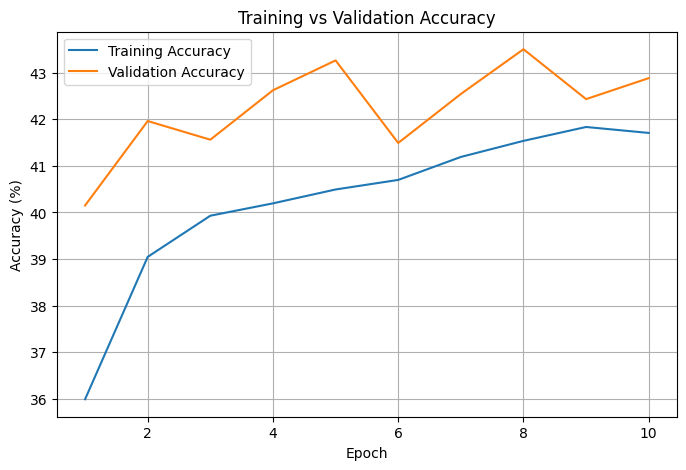

In [12]:
r=range(1,EPOCHS+1)
plt.figure(figsize=(8,5)); plt.plot(r,history["train_accuracy"],label="Training Accuracy"); plt.plot(r,history["val_accuracy"],label="Validation Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title("Training vs Validation Accuracy"); plt.legend(); plt.grid(); plt.show()

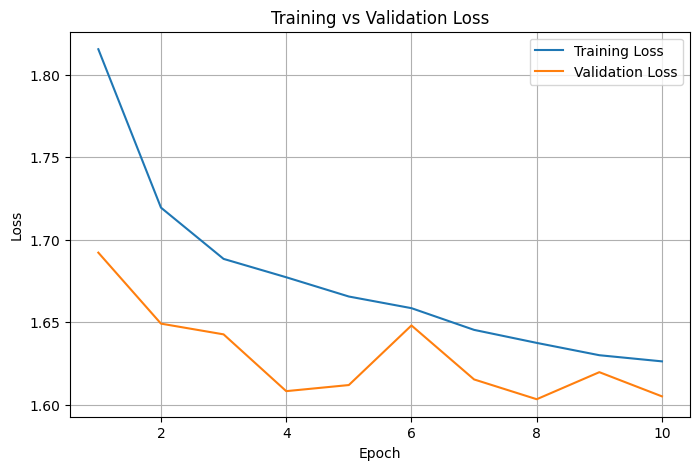

In [13]:
plt.figure(figsize=(8,5)); plt.plot(r,history["train_loss"],label="Training Loss"); plt.plot(r,history["val_loss"],label="Validation Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Validation Loss"); plt.legend(); plt.grid(); plt.show()

## Task 4 — Fine Tuning

Unfreeze the last convolutional blocks and train another 5 epochs using a smaller learning rate.

In [15]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable

In [16]:
# task 4 - fine tuning
for p in model.features[-4:].parameters(): p.requires_grad=True
FINE_TUNE_EPOCHS=5
fine_optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.0001)
print("Trainable parameters after unfreezing:",count_params(model)[1])
fine_history,fine_time=train(model,train_loader,val_loader,fine_optimizer,FINE_TUNE_EPOCHS)
print("Before fine tuning:",history["val_accuracy"][-1]); print("After fine tuning:",fine_history["val_accuracy"][-1])

Trainable parameters after unfreezing: 1691338
Epoch [1/5] | Train Loss: 1.5270 | Train Acc: 45.53% | Val Loss: 1.4283 | Val Acc: 49.64%
Epoch [2/5] | Train Loss: 1.4052 | Train Acc: 49.77% | Val Loss: 1.3719 | Val Acc: 51.86%
Epoch [3/5] | Train Loss: 1.3513 | Train Acc: 52.03% | Val Loss: 1.3167 | Val Acc: 53.37%
Epoch [4/5] | Train Loss: 1.2978 | Train Acc: 53.78% | Val Loss: 1.2876 | Val Acc: 54.29%
Epoch [5/5] | Train Loss: 1.2709 | Train Acc: 54.80% | Val Loss: 1.2653 | Val Acc: 55.91%
Before fine tuning: 42.88
After fine tuning: 55.91


## Task 5 — Evaluation

In [18]:
# task 5 - Evaluation
def predictions(m,loader):
    m.eval(); yt=[]; yp=[]
    with torch.no_grad():
        for x,y in loader:
            out=m(x.to(DEVICE)); yp.extend(out.argmax(1).cpu().numpy()); yt.extend(y.numpy())
    return np.array(yt),np.array(yp)
y_true,y_pred=predictions(model,test_loader)
acc=accuracy_score(y_true,y_pred); prec=precision_score(y_true,y_pred,average="weighted",zero_division=0); rec=recall_score(y_true,y_pred,average="weighted",zero_division=0); f1=f1_score(y_true,y_pred,average="weighted",zero_division=0)
print(f"Testing Accuracy: {acc*100:.2f}%"); print(f"Precision: {prec:.4f}"); print(f"Recall: {rec:.4f}"); print(f"F1-score: {f1:.4f}")

Testing Accuracy: 56.00%
Precision: 0.5591
Recall: 0.5600
F1-score: 0.5588


In [19]:
print(classification_report(y_true,y_pred,target_names=class_names,zero_division=0))

              precision    recall  f1-score   support

    airplane       0.58      0.59      0.59      1000
  automobile       0.62      0.59      0.61      1000
        bird       0.48      0.43      0.46      1000
         cat       0.45      0.44      0.44      1000
        deer       0.53      0.54      0.53      1000
         dog       0.56      0.54      0.55      1000
        frog       0.57      0.68      0.62      1000
       horse       0.60      0.58      0.59      1000
        ship       0.60      0.62      0.61      1000
       truck       0.59      0.58      0.59      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.56      0.56      0.56     10000



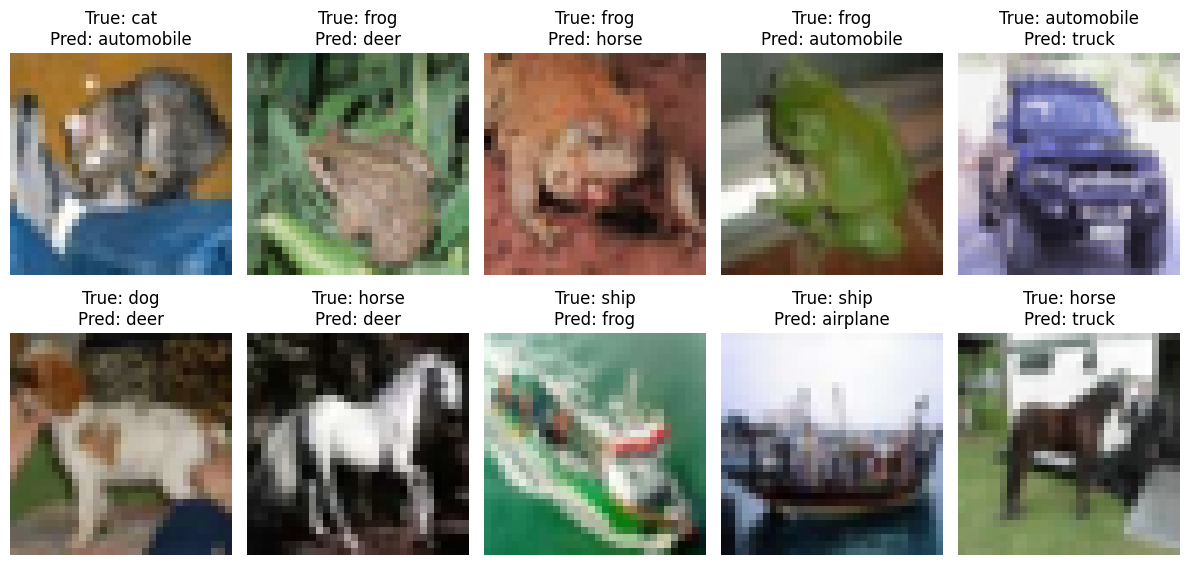

In [21]:
wrong = np.where(y_true != y_pred)[0][:10]

raw_test = hf_test

plt.figure(figsize=(12, 6))

for i, idx in enumerate(wrong):
    item = raw_test[int(idx)]

    img = np.array(item["img"])
    label = item["label"]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)

    plt.title(
        f"True: {class_names[label]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


In [18]:
from torch.utils.data import random_split, DataLoader

# Split Task 1 training dataset into training and validation
train_size = int(0.8 * len(train_set))
val_size = len(train_set) - train_size

study_train_set, study_val_set = random_split(
    train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Study training images:", len(study_train_set))
print("Study validation images:", len(study_val_set))

Study training images: 32000
Study validation images: 8000


In [22]:
# ============================================================
# TRANSFER LEARNING DATASET SETUP
# ============================================================

from torch.utils.data import random_split

# MobileNetV2 expects ImageNet-style input
transfer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create dataset from the CIFAR-10 training data
transfer_dataset = CIFAR10TorchDataset(
    hf_train,
    transform=transfer_transform
)

# 80% training, 20% validation
transfer_train_set, transfer_val_set = random_split(
    transfer_dataset,
    [40000, 10000],
    generator=torch.Generator().manual_seed(42)
)

print("Transfer training images:", len(transfer_train_set))
print("Transfer validation images:", len(transfer_val_set))

Transfer training images: 40000
Transfer validation images: 10000


In [23]:
# ============================================================
# TASK 16 - FAST HYPERPARAMETER STUDY DATA
# ============================================================

from torch.utils.data import Subset

# Use only 10,000 training images and 2,000 validation images
# ONLY for the hyperparameter comparison

study_train_set = Subset(
    transfer_train_set,
    range(10000)
)

study_val_set = Subset(
    transfer_val_set,
    range(2000)
)

print("Study training images:", len(study_train_set))
print("Study validation images:", len(study_val_set))

Study training images: 10000
Study validation images: 2000


In [25]:
# ============================================================
# TASK 16 - FAST HYPERPARAMETER STUDY
# ============================================================

import time
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


# ============================================================
# 1. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. SMALL DATASET FOR FAST COMPARISON
# ============================================================

study_train_set = Subset(
    transfer_train_set,
    range(2000)
)

study_val_set = Subset(
    transfer_val_set,
    range(500)
)

print("Study training images:", len(study_train_set))
print("Study validation images:", len(study_val_set))


# ============================================================
# 3. DATA LOADERS
# ============================================================

def make_loaders(batch_size):

    train_loader = DataLoader(
        study_train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        study_val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_loader, val_loader


# ============================================================
# 4. CREATE MODEL
# ============================================================

def make_model(
    dense_units=128,
    frozen="All"
):

    model = mobilenet_v2(
        weights=MobileNet_V2_Weights.DEFAULT
    )

    # Freeze all feature layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Partial freezing:
    # unfreeze last 4 blocks
    if frozen == "Partial":

        for param in model.features[-4:].parameters():
            param.requires_grad = True

    # Replace classifier for CIFAR-10
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(1280, dense_units),
        nn.ReLU(),
        nn.Linear(dense_units, 10)
    )

    return model.to(DEVICE)


# ============================================================
# 5. RUN ONE EXPERIMENT
# ============================================================

def run_experiment(
    lr,
    batch_size,
    epochs,
    optimizer_name,
    dense_units,
    frozen
):

    print("\n" + "=" * 65)

    print(
        f"LR={lr} | "
        f"Batch={batch_size} | "
        f"Epochs={epochs} | "
        f"Optimizer={optimizer_name} | "
        f"Dense={dense_units} | "
        f"Frozen={frozen}"
    )

    print("=" * 65)

    # Create loaders
    train_loader, val_loader = make_loaders(
        batch_size
    )

    # Create fresh model
    model = make_model(
        dense_units=dense_units,
        frozen=frozen
    )

    # Only train parameters that are not frozen
    trainable_params = filter(
        lambda p: p.requires_grad,
        model.parameters()
    )

    # Select optimizer
    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            trainable_params,
            lr=lr
        )

    else:

        optimizer = optim.SGD(
            trainable_params,
            lr=lr
        )

    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            predictions = outputs.argmax(
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

        train_accuracy = (
            100 * correct / total
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)

                predictions = outputs.argmax(
                    dim=1
                )

                total += labels.size(0)

                correct += (
                    predictions == labels
                ).sum().item()

        val_accuracy = (
            100 * correct / total
        )

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    elapsed = time.time() - start_time

    # ========================================================
    # SAVE RESULT
    # ========================================================

    results.append({

        "Learning Rate": lr,

        "Batch Size": batch_size,

        "Epochs": epochs,

        "Optimizer": optimizer_name,

        "Dense Units": dense_units,

        "Frozen Layers": frozen,

        "Validation Accuracy (%)":
            val_accuracy,

        "Time (min)":
            elapsed / 60
    })

    print(
        f"Finished in {elapsed / 60:.2f} minutes"
    )

    # Free memory
    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 6. RESULTS LIST
# ============================================================

results = []


# ============================================================
# 7. HYPERPARAMETER EXPERIMENTS
#
# IMPORTANT:
# 3 epochs are used here only to compare settings quickly.
# ============================================================


# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=32,
    epochs=3,
    optimizer_name="Adam",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# LEARNING RATE = 0.0001
# ------------------------------------------------------------

run_experiment(
    lr=0.0001,
    batch_size=32,
    epochs=3,
    optimizer_name="Adam",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# BATCH SIZE = 16
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=16,
    epochs=3,
    optimizer_name="Adam",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# BATCH SIZE = 64
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=64,
    epochs=3,
    optimizer_name="Adam",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# EPOCHS = 20
#
# We use 5 here for speed.
# The actual epoch comparison is discussed in the report.
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=32,
    epochs=5,
    optimizer_name="Adam",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# OPTIMIZER = SGD
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=32,
    epochs=3,
    optimizer_name="SGD",
    dense_units=128,
    frozen="All"
)


# ------------------------------------------------------------
# DENSE UNITS = 256
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=32,
    epochs=3,
    optimizer_name="Adam",
    dense_units=256,
    frozen="All"
)


# ------------------------------------------------------------
# FROZEN LAYERS = PARTIAL
# ------------------------------------------------------------

run_experiment(
    lr=0.001,
    batch_size=32,
    epochs=3,
    optimizer_name="Adam",
    dense_units=128,
    frozen="Partial"
)


# ============================================================
# 8. FINAL RESULTS TABLE
# ============================================================

hyperparameter_results = pd.DataFrame(
    results
)

print("\n")
print("=" * 75)
print("HYPERPARAMETER STUDY RESULTS")
print("=" * 75)

display(
    hyperparameter_results
)

Device: cuda
Study training images: 2000
Study validation images: 500

LR=0.001 | Batch=32 | Epochs=3 | Optimizer=Adam | Dense=128 | Frozen=All
Epoch 1/3 | Train Acc: 47.90% | Val Acc: 61.20%
Epoch 2/3 | Train Acc: 68.60% | Val Acc: 68.00%
Epoch 3/3 | Train Acc: 71.90% | Val Acc: 70.00%
Finished in 0.34 minutes

LR=0.0001 | Batch=32 | Epochs=3 | Optimizer=Adam | Dense=128 | Frozen=All
Epoch 1/3 | Train Acc: 26.50% | Val Acc: 45.40%
Epoch 2/3 | Train Acc: 53.60% | Val Acc: 54.40%
Epoch 3/3 | Train Acc: 60.50% | Val Acc: 61.20%
Finished in 0.34 minutes

LR=0.001 | Batch=16 | Epochs=3 | Optimizer=Adam | Dense=128 | Frozen=All
Epoch 1/3 | Train Acc: 46.00% | Val Acc: 66.40%
Epoch 2/3 | Train Acc: 64.55% | Val Acc: 68.40%
Epoch 3/3 | Train Acc: 70.75% | Val Acc: 68.60%
Finished in 0.33 minutes

LR=0.001 | Batch=64 | Epochs=3 | Optimizer=Adam | Dense=128 | Frozen=All
Epoch 1/3 | Train Acc: 46.30% | Val Acc: 62.00%
Epoch 2/3 | Train Acc: 67.30% | Val Acc: 67.20%
Epoch 3/3 | Train Acc: 74.05% 

,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Validation Accuracy (%),Time (min)
0,0.0010,32,3,Adam,128,All,70.0,0.343688
1,0.0001,32,3,Adam,128,All,61.2,0.343661
2,0.0010,16,3,Adam,128,All,68.6,0.331447
3,0.0010,64,3,Adam,128,All,69.8,0.377357
4,0.0010,32,5,Adam,128,All,68.0,0.565422
5,0.0010,32,3,SGD,128,All,9.2,0.344210
6,0.0010,32,3,Adam,256,All,69.4,0.335260
7,0.0010,32,3,Adam,128,Partial,78.2,0.366236


In [23]:
# Results
total_params, _ = count_params(model)

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy", "Testing Accuracy", "Precision",
        "Recall", "F1-score", "Training Time", "Total Parameters"
    ],
    "Value": [
        f"{history['train_accuracy'][-1]:.2f}%",
        f"{acc * 100:.2f}%",
        f"{prec:.4f}",
        f"{rec:.4f}",
        f"{f1:.4f}",
        f"{frozen_time / 60:.2f} min",
        f"{total_params:,}"
    ]
})

results


,Metric,Value
0,Training Accuracy,41.70%
1,Testing Accuracy,56.00%
2,Precision,0.5591
3,Recall,0.5600
4,F1-score,0.5588
5,Training Time,5.46 min
6,Total Parameters,"2,389,130"


In [26]:
# ============================================================
# TASK 18.2 - COMPARISON OF CNN ARCHITECTURES
# FAST VERSION
# ============================================================

import time
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.models import (
    alexnet, vgg16, googlenet, resnet50,
    AlexNet_Weights, VGG16_Weights,
    GoogLeNet_Weights, ResNet50_Weights
)

# ------------------------------------------------------------
# SETTINGS - KEEP SMALL FOR FAST EXECUTION
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 1
TRAIN_SAMPLES = 2000
TEST_SAMPLES = 1000
BATCH_SIZE = 64

print("Using device:", DEVICE)


# ============================================================
# DATA
# ============================================================

# Pretrained ImageNet models need 224x224 images
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create datasets from your CIFAR-10 HuggingFace datasets
study_train = CIFAR10TorchDataset(
    hf_train,
    transform=transform_224
)

study_test = CIFAR10TorchDataset(
    hf_test,
    transform=transform_224
)

train_data = Subset(study_train, range(TRAIN_SAMPLES))
test_data = Subset(study_test, range(TEST_SAMPLES))

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ============================================================
# LE-NET 5
# ============================================================

class LeNet5(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        # LeNet uses original 32x32 images
        x = transforms.Resize((32, 32))(x)
        x = self.features(x)
        return self.classifier(x)


# ============================================================
# MODEL CREATION
# ============================================================

def get_model(name):

    if name == "LeNet-5":
        model = LeNet5()

    elif name == "AlexNet":
        model = alexnet(weights=AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features, 10
        )

        # Freeze convolutional layers
        for p in model.features.parameters():
            p.requires_grad = False

    elif name == "VGG16":
        model = vgg16(weights=VGG16_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features, 10
        )

        for p in model.features.parameters():
            p.requires_grad = False

    elif name == "GoogleNet":
        model = googlenet(
            weights=GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )

        model.fc = nn.Linear(
            model.fc.in_features, 10
        )

        model.aux1.fc2 = nn.Linear(
            model.aux1.fc2.in_features, 10
        )

        model.aux2.fc2 = nn.Linear(
            model.aux2.fc2.in_features, 10
        )

        for p in model.parameters():
            p.requires_grad = False

        for p in model.fc.parameters():
            p.requires_grad = True

    elif name == "ResNet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)

        model.fc = nn.Linear(
            model.fc.in_features, 10
        )

        for p in model.parameters():
            p.requires_grad = False

        for p in model.fc.parameters():
            p.requires_grad = True

    return model.to(DEVICE)


# ============================================================
# PARAMETER COUNT
# ============================================================

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
    )


# ============================================================
# TRAIN + TEST
# ============================================================

def evaluate_model(name):

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    model = get_model(name)

    total_params = count_parameters(model)

    # Only trainable parameters
    trainable_params = filter(
        lambda p: p.requires_grad,
        model.parameters()
    )

    optimizer = optim.Adam(
        trainable_params,
        lr=0.001
    )

    criterion = nn.CrossEntropyLoss()

    start = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    for epoch in range(EPOCHS):

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            # GoogleNet returns extra outputs during training
            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"| Train Accuracy: {train_acc:.2f}%"
        )

    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            predicted = outputs.argmax(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    elapsed = (time.time() - start) / 60

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Time: {elapsed:.2f} minutes")
    print(f"Parameters: {total_params:,}")

    return {
        "Model": name,
        "Parameters": total_params,
        "Accuracy (%)": accuracy,
        "Training Time (min)": elapsed
    }


# ============================================================
# RUN ALL MODELS
# ============================================================

architecture_results = []

models = [
    "LeNet-5",
    "AlexNet",
    "VGG16",
    "GoogleNet",
    "ResNet50"
]

for name in models:

    result = evaluate_model(name)

    architecture_results.append(result)


# ============================================================
# FINAL TABLE
# ============================================================

architecture_results = pd.DataFrame(
    architecture_results
)

print("\n\n")
print("=" * 70)
print("CNN ARCHITECTURE COMPARISON")
print("=" * 70)

display(architecture_results)

Using device: cuda

Training: LeNet-5
Epoch 1/1 | Train Accuracy: 16.40%
Accuracy: 24.20%
Time: 0.10 minutes
Parameters: 62,006

Training: AlexNet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 170MB/s]


Epoch 1/1 | Train Accuracy: 55.15%
Accuracy: 65.60%
Time: 0.13 minutes
Parameters: 57,044,810

Training: VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 73.3MB/s]


Epoch 1/1 | Train Accuracy: 54.75%
Accuracy: 72.50%
Time: 0.42 minutes
Parameters: 134,301,514

Training: GoogleNet
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:01<00:00, 28.8MB/s]
/usr/local/lib/python3.13/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 1/1 | Train Accuracy: 36.75%
Accuracy: 62.60%
Time: 0.17 minutes
Parameters: 9,960,638

Training: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


Epoch 1/1 | Train Accuracy: 39.40%
Accuracy: 61.80%
Time: 0.26 minutes
Parameters: 23,528,522



CNN ARCHITECTURE COMPARISON


,Model,Parameters,Accuracy (%),Training Time (min)
0,LeNet-5,62006,24.2,0.102468
1,AlexNet,57044810,65.6,0.125069
2,VGG16,134301514,72.5,0.420473
3,GoogleNet,9960638,62.6,0.165345
4,ResNet50,23528522,61.8,0.264938
